In [8]:
import torch, torch.nn as nn
from sentence_transformers import SentenceTransformer
import json
import matplotlib.pyplot as plt
import numpy as np

In [9]:
class Head(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 64), nn.ReLU(),   # hidden 0
            nn.Linear(64, 64),  nn.ReLU(),   # hidden 1
            nn.Linear(64, 64),  nn.ReLU(),   # hidden 2  ← non-linear activation here (post-ReLU)
            nn.Linear(64, 64),  nn.ReLU(),   # hidden 3
            nn.Linear(64, 8),                # logits
        )
    def forward(self, x):
        return self.layers(x)

In [10]:
# --- 2. Load encoder (downloaded from HF) and head (local file) ---
enc = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
m = Head()
m.load_state_dict(torch.load("model.pt", map_location="cpu", weights_only=False))
m.eval()

Head(
  (layers): Sequential(
    (0): Linear(in_features=384, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=8, bias=True)
  )
)

In [11]:
# --- 3. Get predictions ---
X = []
Y = []

with open("data/test.jsonl") as f:
    for line in f:
        example = json.loads(line)
        X.append(example["text"])
        Y.append(example["labels"])

actuals = torch.tensor(Y).int()

with torch.no_grad():
    embeddings = torch.from_numpy(
        enc.encode(X, convert_to_numpy=True)   # (N, 384), mean-pooled
    )
    logits = m(embeddings)                          # (N, 8)
    probs  = torch.sigmoid(logits)                  # (N, 8) - independent per feature
    preds  = (probs > 0.5).int()

In [12]:
# --- 3b. Sanity-check model performance on the test set ---
with open("feature_names.json") as f:
    feature_names = json.load(f)

label_acc = (preds == actuals).float().mean().item()
row_acc = (preds == actuals).all(dim=1).float().mean().item()
per_feature_acc = (preds == actuals).float().mean(dim=0)
mismatches = int((preds != actuals).sum().item())

print(f"Test examples: {len(X)}")
print(f"Label accuracy: {label_acc:.3%}")
print(f"Exact-row accuracy: {row_acc:.3%}")
print("Per-feature accuracy:")
for name, acc in zip(feature_names, per_feature_acc):
    print(f"  {name:<12} {acc.item():.3%}")

print(f"Mismatched labels: {mismatches} / {actuals.numel()}")

min_label_acc = 0.95
min_row_acc = 0.80
assert label_acc >= min_label_acc and row_acc >= min_row_acc, (
    f"Model sanity check failed: label_acc={label_acc:.3%}, row_acc={row_acc:.3%}"
)
print("Model sanity check passed.")

Test examples: 1500
Label accuracy: 98.225%
Exact-row accuracy: 87.067%
Per-feature accuracy:
  number       97.600%
  question     100.000%
  color        97.267%
  food         98.600%
  sentiment    98.200%
  country      96.400%
  person       99.867%
  body_part    97.867%
Mismatched labels: 213 / 12000
Model sanity check passed.


In [15]:
# --- 4. Get activations at the right spot (post-ReLU of hidden 2) ---
# layers[0:6] = Linear, ReLU, Linear, ReLU, Linear, ReLU  → output is hidden 2 post-ReLU
with torch.no_grad():
    layer2_acts = m.layers[:6](embeddings)

number: actual-label probe acc=0.9733
question: actual-label probe acc=1.0000
color: actual-label probe acc=0.9787
food: actual-label probe acc=0.9867
sentiment: actual-label probe acc=0.9867
country: actual-label probe acc=0.5413
person: actual-label probe acc=0.9947
body_part: actual-label probe acc=0.9733


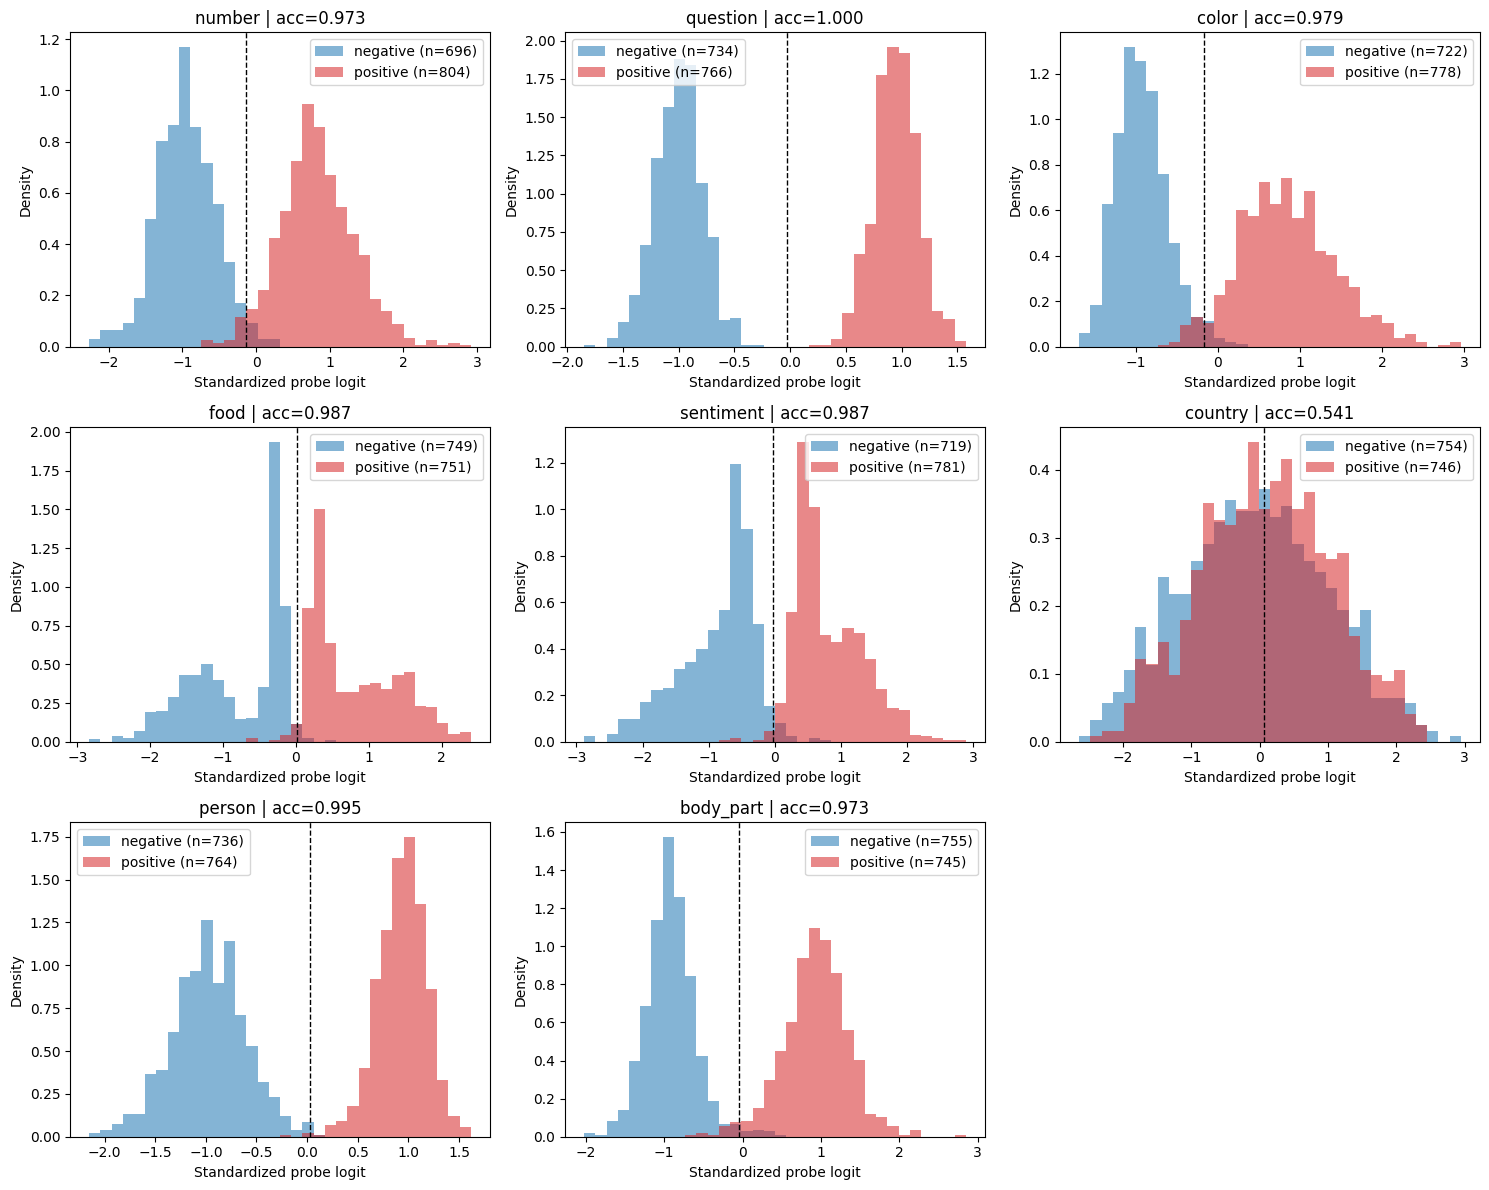

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import math

with open("feature_names.json") as f:
    feature_names = json.load(f)

acts_np = layer2_acts.detach().cpu().numpy()
actuals_np = actuals.detach().cpu().numpy()
indices = np.arange(len(acts_np))

n_classes = probs.shape[1]
n_cols = 3
n_rows = math.ceil(n_classes / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    squeeze=False,
)

for i in range(n_classes):
    y = actuals_np[:, i]
    train_idx, test_idx = train_test_split(
        indices,
        test_size=0.25,
        random_state=0,
        stratify=y,
    )

    clf = LogisticRegression(max_iter=1000)
    clf.fit(acts_np[train_idx], y[train_idx])
    test_acc = clf.score(acts_np[test_idx], y[test_idx])

    train_logit = clf.decision_function(acts_np[train_idx])
    logit = clf.decision_function(acts_np)
    logit_std = train_logit.std()
    if logit_std == 0:
        standardized_logit = logit - train_logit.mean()
        decision_boundary = -train_logit.mean()
    else:
        standardized_logit = (logit - train_logit.mean()) / logit_std
        decision_boundary = (0 - train_logit.mean()) / logit_std

    negatives = standardized_logit[y == 0]
    positives = standardized_logit[y == 1]
    bins = np.linspace(standardized_logit.min(), standardized_logit.max(), 35)
    print(f"{feature_names[i]}: actual-label probe acc={test_acc:.4f}")

    ax = axes[i // n_cols][i % n_cols]

    ax.hist(
        negatives,
        bins=bins,
        density=True,
        alpha=0.55,
        label=f"negative (n={len(negatives)})",
        color="tab:blue",
    )
    ax.hist(
        positives,
        bins=bins,
        density=True,
        alpha=0.55,
        label=f"positive (n={len(positives)})",
        color="tab:red",
    )
    ax.axvline(decision_boundary, color="black", linestyle="--", linewidth=1)

    ax.set_title(f"{feature_names[i]} | acc={test_acc:.3f}")
    ax.set_xlabel("Standardized probe logit")
    ax.set_ylabel("Density")
    ax.legend()

for j in range(n_classes, n_rows * n_cols):
    axes[j // n_cols][j % n_cols].axis("off")

plt.tight_layout()
plt.show()

number: actual-label probe acc=0.9733
question: actual-label probe acc=1.0000
color: actual-label probe acc=0.9787
food: actual-label probe acc=0.9867
sentiment: actual-label probe acc=0.9867
country: actual-label probe acc=0.5413
person: actual-label probe acc=0.9947
body_part: actual-label probe acc=0.9733


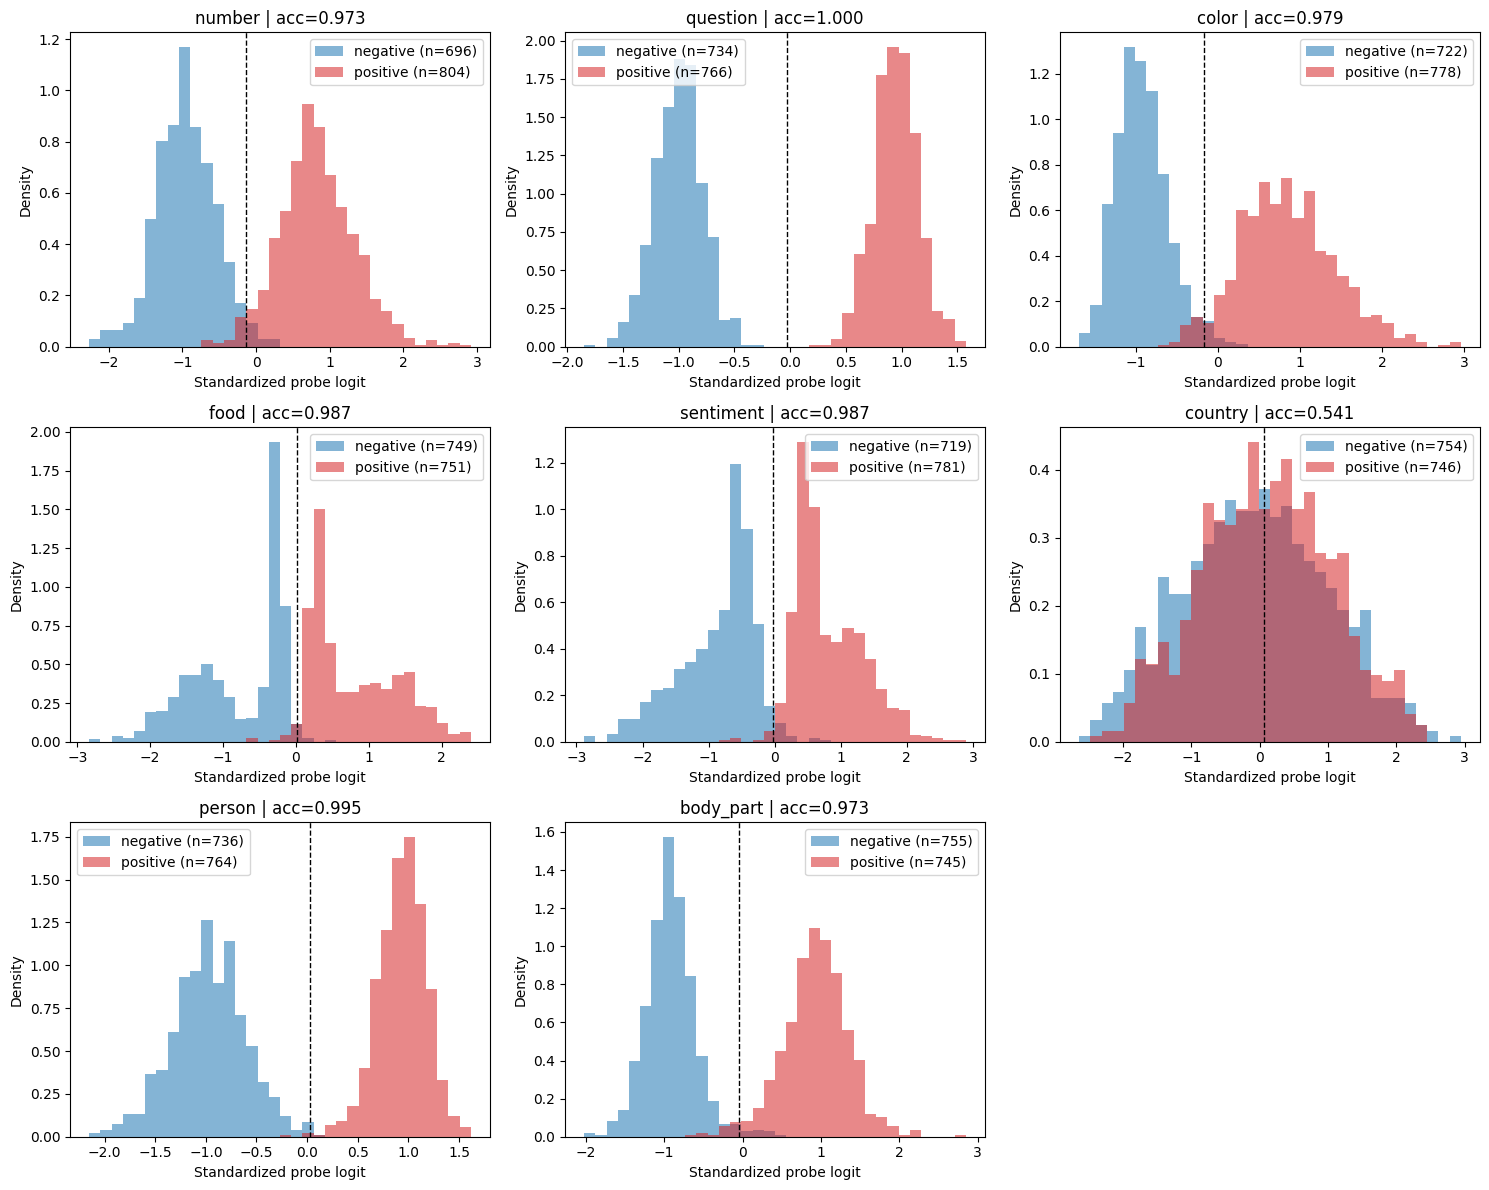


common test examples: 101
food errors: 5 total, 2 in common set
sentiment errors: 5 total, 3 in common set
error overlap (same examples wrong): 0

base rate P(country=1) in common set: 0.535
P(country=1 | food error):      0.500  (n=2)
P(country=1 | sentiment error): 0.667  (n=3)


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import math

with open("feature_names.json") as f:
    feature_names = json.load(f)

acts_np = layer2_acts.detach().cpu().numpy()
actuals_np = actuals.detach().cpu().numpy()
indices = np.arange(len(acts_np))

n_classes = probs.shape[1]
n_cols = 3
n_rows = math.ceil(n_classes / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

# --- for the error-comparison check ---
check_feats = {"food", "sentiment"}
err_sets, test_sets = {}, {}
country = actuals_np[:, feature_names.index("country")].astype(int)

for i in range(n_classes):
    y = actuals_np[:, i]
    train_idx, test_idx = train_test_split(
        indices, test_size=0.25, random_state=0, stratify=y,
    )
    clf = LogisticRegression(max_iter=1000)
    clf.fit(acts_np[train_idx], y[train_idx])
    test_acc = clf.score(acts_np[test_idx], y[test_idx])

    # record errors by ORIGINAL index for food / sentiment
    if feature_names[i] in check_feats:
        preds_te = clf.predict(acts_np[test_idx])
        err_sets[feature_names[i]] = set(test_idx[preds_te != y[test_idx]])
        test_sets[feature_names[i]] = set(test_idx)

    train_logit = clf.decision_function(acts_np[train_idx])
    logit = clf.decision_function(acts_np)
    logit_std = train_logit.std()
    if logit_std == 0:
        standardized_logit = logit - train_logit.mean()
        decision_boundary = -train_logit.mean()
    else:
        standardized_logit = (logit - train_logit.mean()) / logit_std
        decision_boundary = (0 - train_logit.mean()) / logit_std

    negatives = standardized_logit[y == 0]
    positives = standardized_logit[y == 1]
    bins = np.linspace(standardized_logit.min(), standardized_logit.max(), 35)
    print(f"{feature_names[i]}: actual-label probe acc={test_acc:.4f}")

    ax = axes[i // n_cols][i % n_cols]
    ax.hist(negatives, bins=bins, density=True, alpha=0.55,
            label=f"negative (n={len(negatives)})", color="tab:blue")
    ax.hist(positives, bins=bins, density=True, alpha=0.55,
            label=f"positive (n={len(positives)})", color="tab:red")
    ax.axvline(decision_boundary, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{feature_names[i]} | acc={test_acc:.3f}")
    ax.set_xlabel("Standardized probe logit")
    ax.set_ylabel("Density")
    ax.legend()

for j in range(n_classes, n_rows * n_cols):
    axes[j // n_cols][j % n_cols].axis("off")
plt.tight_layout()
plt.show()

# --- error comparison: same count, same examples, country enrichment? ---
err_f, err_s = err_sets["food"], err_sets["sentiment"]
common = test_sets["food"] & test_sets["sentiment"]   # different stratified splits
ef, es = err_f & common, err_s & common

print(f"\ncommon test examples: {len(common)}")
print(f"food errors: {len(err_f)} total, {len(ef)} in common set")
print(f"sentiment errors: {len(err_s)} total, {len(es)} in common set")
print(f"error overlap (same examples wrong): {len(ef & es)}")

base = country[list(common)].mean()
print(f"\nbase rate P(country=1) in common set: {base:.3f}")
if ef: print(f"P(country=1 | food error):      {country[list(ef)].mean():.3f}  (n={len(ef)})")
if es: print(f"P(country=1 | sentiment error): {country[list(es)].mean():.3f}  (n={len(es)})")

number: R^2=0.8082, MSE=0.0477, threshold acc=0.9733
question: R^2=0.9664, MSE=0.0084, threshold acc=1.0000
color: R^2=0.8152, MSE=0.0461, threshold acc=0.9787
food: R^2=0.6389, MSE=0.0903, threshold acc=0.9787
sentiment: R^2=0.7192, MSE=0.0701, threshold acc=0.9840
country: R^2=0.0104, MSE=0.2474, threshold acc=0.5680
person: R^2=0.9166, MSE=0.0208, threshold acc=0.9973
body_part: R^2=0.8705, MSE=0.0324, threshold acc=0.9707


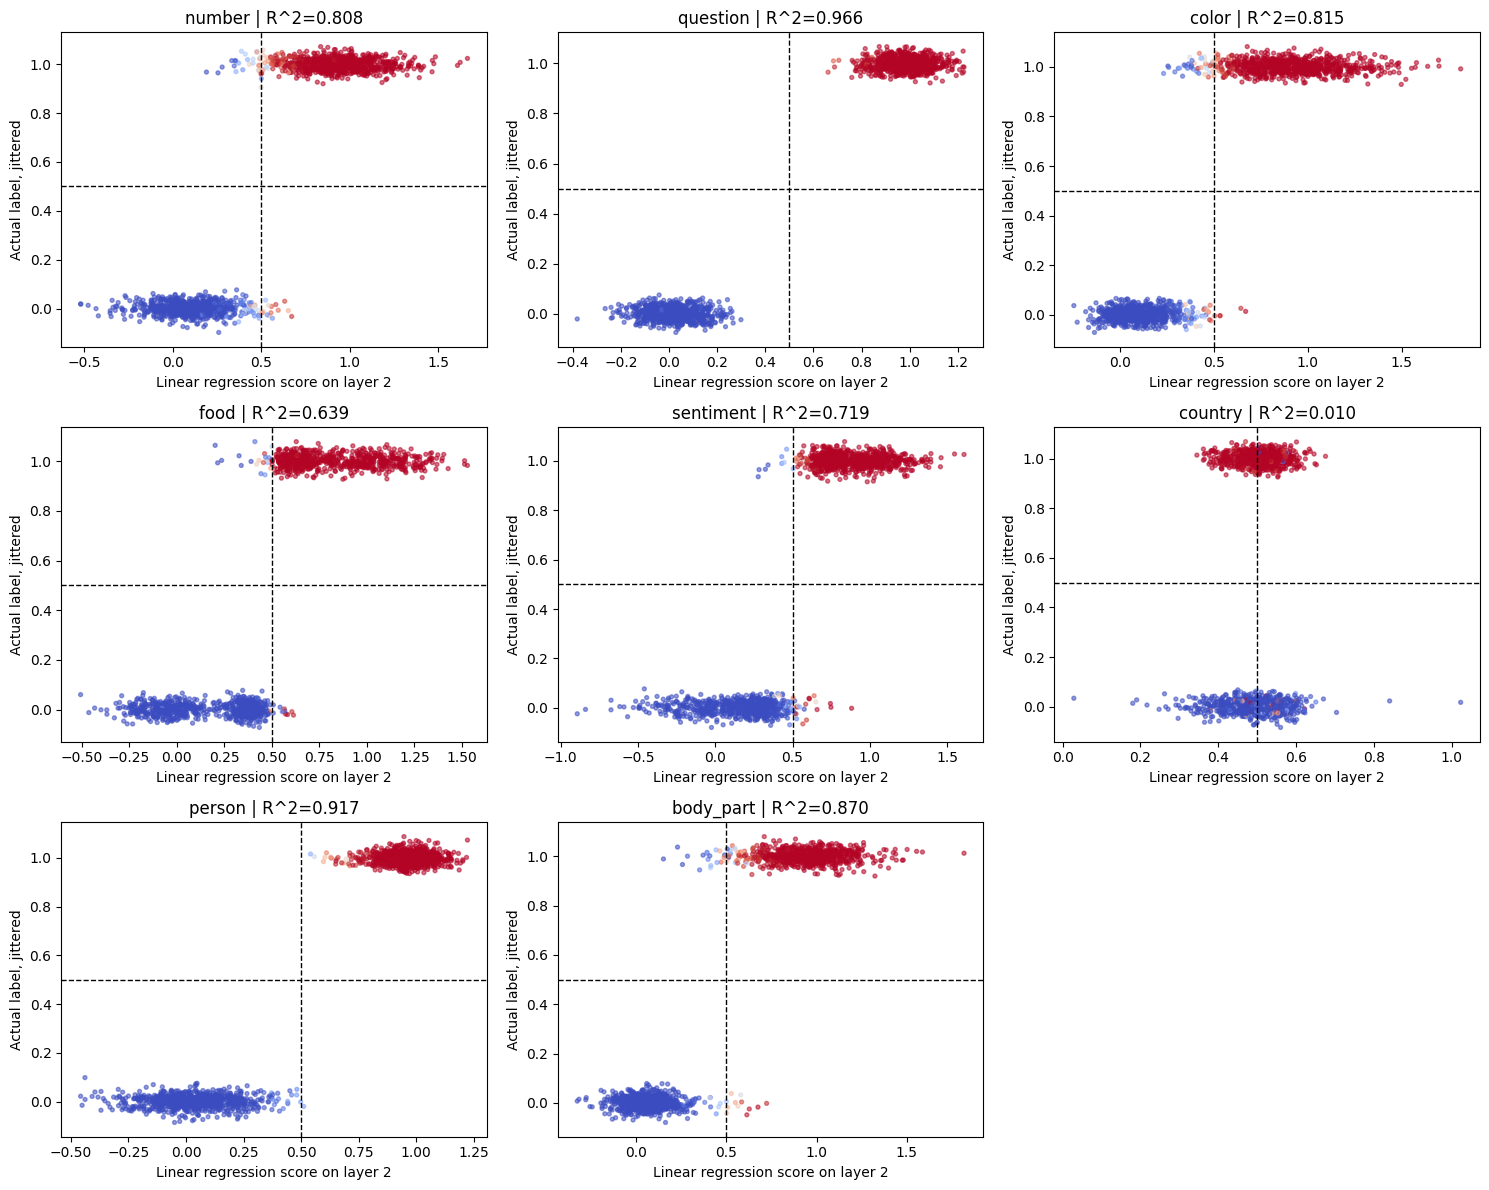

In [7]:
# --- 6. Linear regression scatter at layer 2 ---
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import math

with open("feature_names.json") as f:
    feature_names = json.load(f)

acts_np = layer2_acts.detach().cpu().numpy()
actuals_np = actuals.detach().cpu().numpy().astype(float)
probs_np = probs.detach().cpu().numpy()

n_classes = probs.shape[1]
n_cols = 3
n_rows = math.ceil(n_classes / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    squeeze=False,
)

rng = np.random.default_rng(0)

for i in range(n_classes):
    y = actuals_np[:, i]
    train_idx, test_idx = train_test_split(
        np.arange(len(y)),
        test_size=0.25,
        random_state=0,
        stratify=y,
    )

    reg = LinearRegression()
    reg.fit(acts_np[train_idx], y[train_idx])

    linear_score = reg.predict(acts_np)
    test_score = reg.predict(acts_np[test_idx])
    threshold_acc = ((test_score > 0.5) == y[test_idx]).mean()
    r2 = r2_score(y[test_idx], test_score)
    mse = mean_squared_error(y[test_idx], test_score)

    print(
        f"{feature_names[i]}: R^2={r2:.4f}, MSE={mse:.4f}, "
        f"threshold acc={threshold_acc:.4f}"
    )

    ax = axes[i // n_cols][i % n_cols]
    y_jitter = y + rng.normal(0, 0.025, size=len(y))
    scatter = ax.scatter(
        linear_score,
        y_jitter,
        c=probs_np[:, i],
        cmap="coolwarm",
        s=8,
        alpha=0.55,
    )
    ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
    ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{feature_names[i]} | R^2={r2:.3f}")
    ax.set_xlabel("Linear regression score on layer 2")
    ax.set_ylabel("Actual label, jittered")

for j in range(n_classes, n_rows * n_cols):
    axes[j // n_cols][j % n_cols].axis("off")

plt.tight_layout()
plt.show()

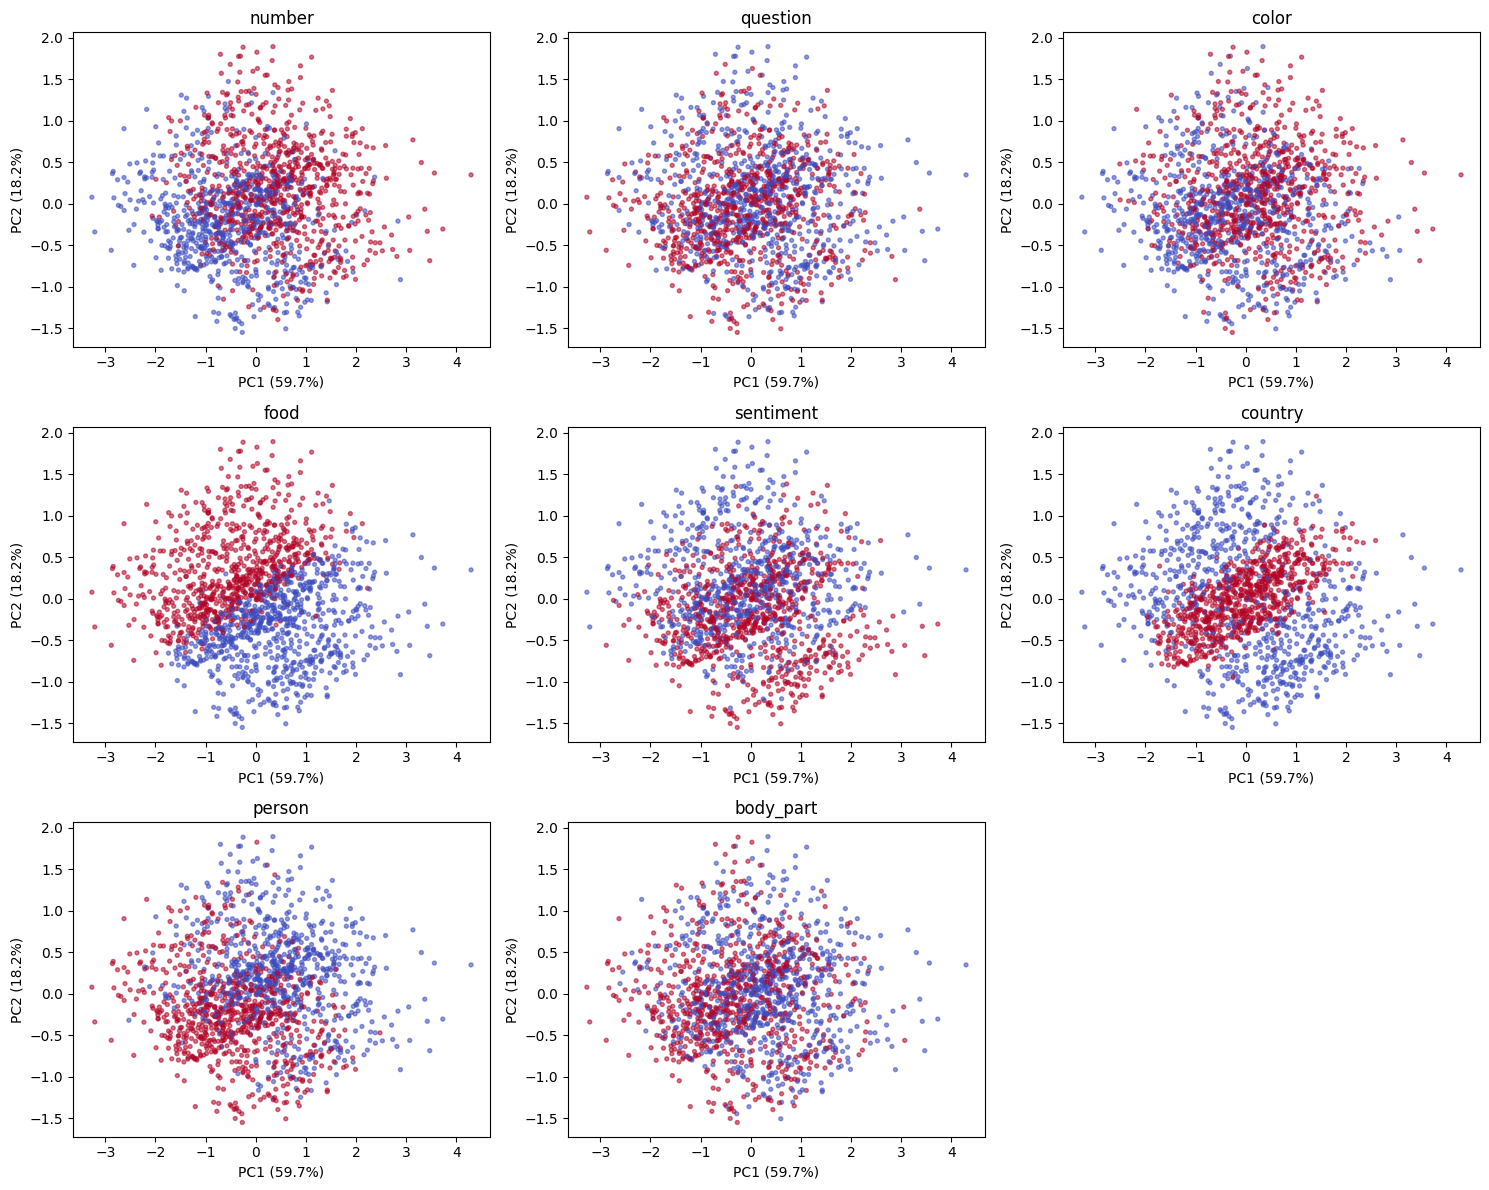

In [8]:
# --- 7. PCA view of layer 2 ---
from sklearn.decomposition import PCA
import math

with open("feature_names.json") as f:
    feature_names = json.load(f)

acts_np = layer2_acts.detach().cpu().numpy()
actuals_np = actuals.detach().cpu().numpy()
probs_np = probs.detach().cpu().numpy()

pca = PCA(n_components=2, random_state=0)
layer2_pca = pca.fit_transform(acts_np)

n_classes = probs.shape[1]
n_cols = 3
n_rows = math.ceil(n_classes / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    squeeze=False,
)

for i in range(n_classes):
    ax = axes[i // n_cols][i % n_cols]
    scatter = ax.scatter(
        layer2_pca[:, 0],
        layer2_pca[:, 1],
        c=actuals_np[:, i],
        cmap="coolwarm",
        s=8,
        alpha=0.55,
        vmin=0,
        vmax=1,
    )
    ax.set_title(feature_names[i])
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")

for j in range(n_classes, n_rows * n_cols):
    axes[j // n_cols][j % n_cols].axis("off")

plt.tight_layout()
plt.show()

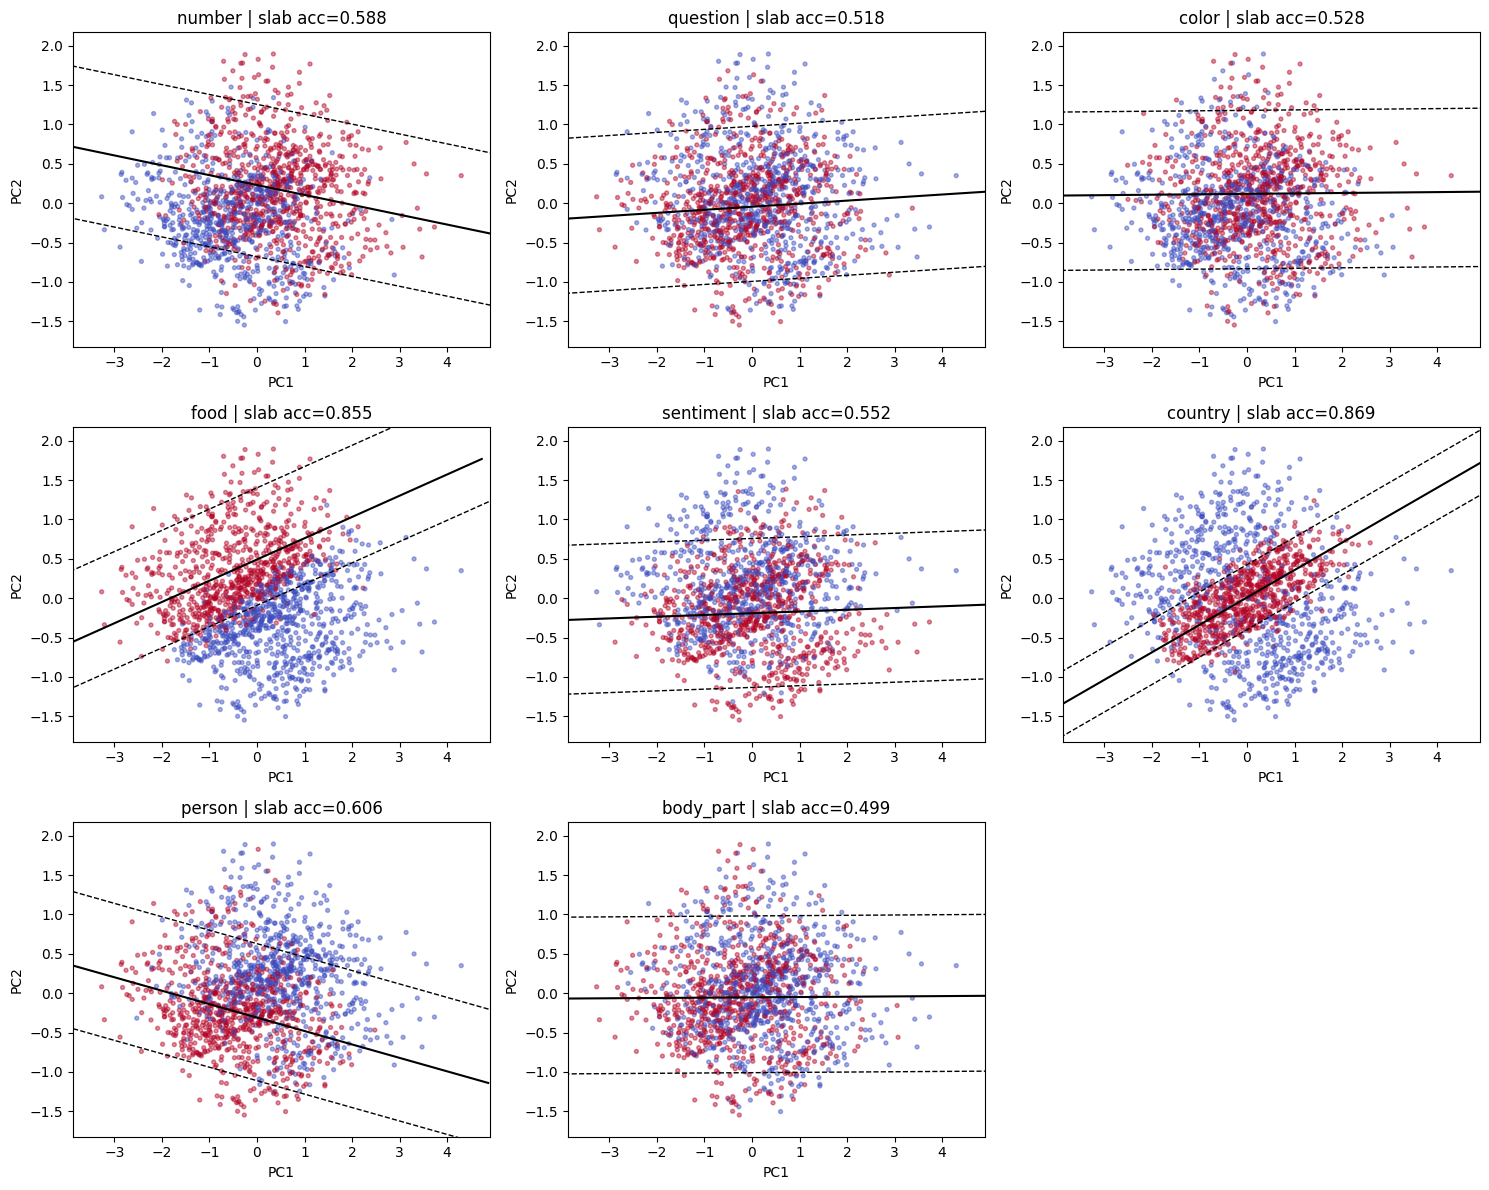

In [9]:
# --- 8. PCA ridge/slab fit from positive points ---
from sklearn.decomposition import PCA
import math

with open("feature_names.json") as f:
    feature_names = json.load(f)

acts_np = layer2_acts.detach().cpu().numpy()
actuals_np = actuals.detach().cpu().numpy()

if "layer2_pca" not in globals():
    pca = PCA(n_components=2, random_state=0)
    layer2_pca = pca.fit_transform(acts_np)

n_classes = probs.shape[1]
n_cols = 3
n_rows = math.ceil(n_classes / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    squeeze=False,
)

plot_min = layer2_pca.min(axis=0)
plot_max = layer2_pca.max(axis=0)
plot_range = plot_max - plot_min
plot_min = plot_min - 0.08 * plot_range
plot_max = plot_max + 0.08 * plot_range
line_t = np.linspace(-0.65, 0.65, 200)

for i in range(n_classes):
    ax = axes[i // n_cols][i % n_cols]
    y = actuals_np[:, i]
    positives = layer2_pca[y == 1]

    ax.scatter(
        layer2_pca[:, 0],
        layer2_pca[:, 1],
        c=y,
        cmap="coolwarm",
        s=8,
        alpha=0.45,
        vmin=0,
        vmax=1,
    )

    center = positives.mean(axis=0)
    _, _, vh = np.linalg.svd(positives - center, full_matrices=False)
    ridge_dir = vh[0]
    normal_dir = np.array([-ridge_dir[1], ridge_dir[0]])

    signed_distance = (positives - center) @ normal_dir
    lower, upper = np.quantile(signed_distance, [0.05, 0.95])
    width = upper - lower

    span = np.linalg.norm(plot_range) * line_t
    ridge = center + np.outer(span, ridge_dir)
    lower_line = ridge + lower * normal_dir
    upper_line = ridge + upper * normal_dir

    ax.plot(ridge[:, 0], ridge[:, 1], color="black", linewidth=1.5, label="positive ridge")
    ax.plot(lower_line[:, 0], lower_line[:, 1], color="black", linestyle="--", linewidth=1)
    ax.plot(upper_line[:, 0], upper_line[:, 1], color="black", linestyle="--", linewidth=1)

    all_signed_distance = (layer2_pca - center) @ normal_dir
    inside = (all_signed_distance >= lower) & (all_signed_distance <= upper)
    slab_acc = (inside == y.astype(bool)).mean()

    ax.set_title(f"{feature_names[i]} | slab acc={slab_acc:.3f}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_xlim(plot_min[0], plot_max[0])
    ax.set_ylim(plot_min[1], plot_max[1])

for j in range(n_classes, n_rows * n_cols):
    axes[j // n_cols][j % n_cols].axis("off")

plt.tight_layout()
plt.show()

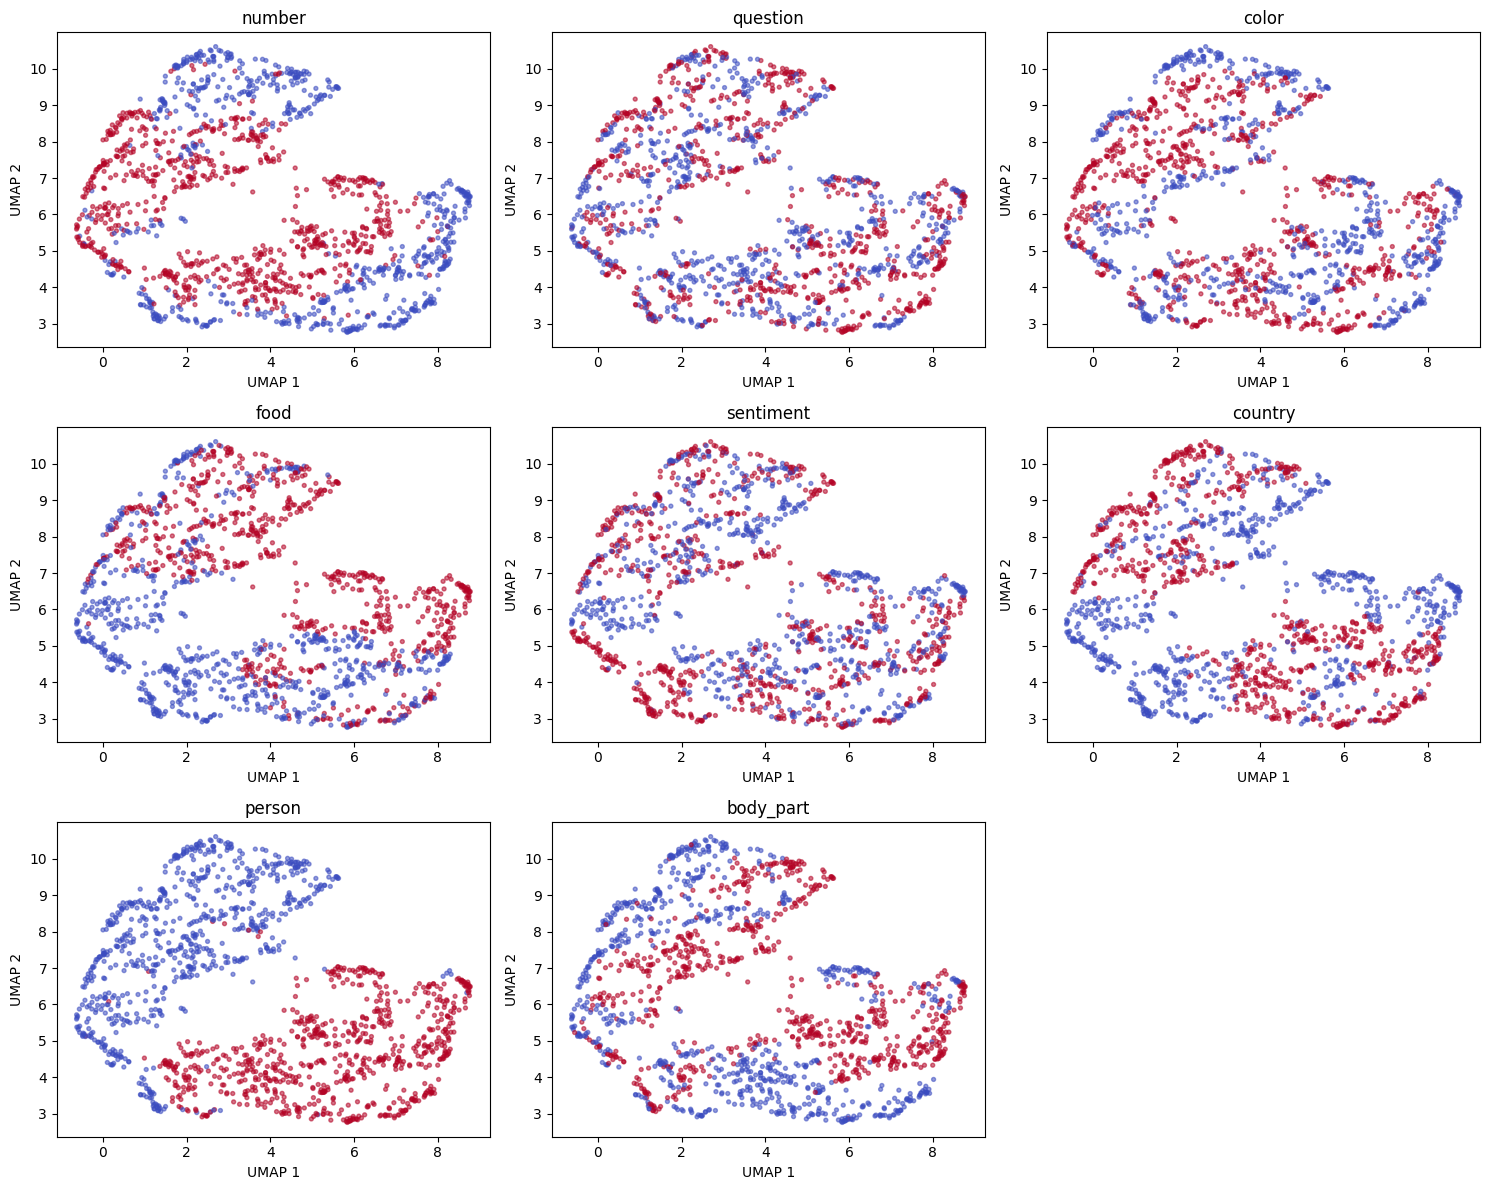

In [10]:
# --- 9. UMAP view of layer 2 ---
import math

try:
    from umap import UMAP
except ImportError as exc:
    raise ImportError("UMAP is not installed. Install it with: pip install umap-learn") from exc

with open("feature_names.json") as f:
    feature_names = json.load(f)

acts_np = layer2_acts.detach().cpu().numpy()
actuals_np = actuals.detach().cpu().numpy()
probs_np = probs.detach().cpu().numpy()

umap_model = UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric="euclidean",
    random_state=0,
)
layer2_umap = umap_model.fit_transform(acts_np)

n_classes = probs.shape[1]
n_cols = 3
n_rows = math.ceil(n_classes / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    squeeze=False,
)

for i in range(n_classes):
    ax = axes[i // n_cols][i % n_cols]
    scatter = ax.scatter(
        layer2_umap[:, 0],
        layer2_umap[:, 1],
        c=actuals_np[:, i],
        cmap="coolwarm",
        s=8,
        alpha=0.55,
        vmin=0,
        vmax=1,
    )
    ax.set_title(feature_names[i])
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")

for j in range(n_classes, n_rows * n_cols):
    axes[j // n_cols][j % n_cols].axis("off")

plt.tight_layout()
plt.show()

number                   base=0.54  R^2=+0.808  lin_auc=0.997  mlp_auc=0.997  gap=-0.000
question                 base=0.51  R^2=+0.966  lin_auc=1.000  mlp_auc=1.000  gap=-0.000
color                    base=0.52  R^2=+0.815  lin_auc=0.999  mlp_auc=0.998  gap=-0.000
food                     base=0.50  R^2=+0.639  lin_auc=0.996  mlp_auc=0.991  gap=-0.005
sentiment                base=0.52  R^2=+0.719  lin_auc=0.996  mlp_auc=0.995  gap=-0.001
country                  base=0.50  R^2=+0.010  lin_auc=0.559  mlp_auc=0.935  gap=+0.376
person                   base=0.51  R^2=+0.917  lin_auc=1.000  mlp_auc=0.998  gap=-0.002
body_part                base=0.50  R^2=+0.870  lin_auc=0.998  mlp_auc=0.999  gap=+0.000


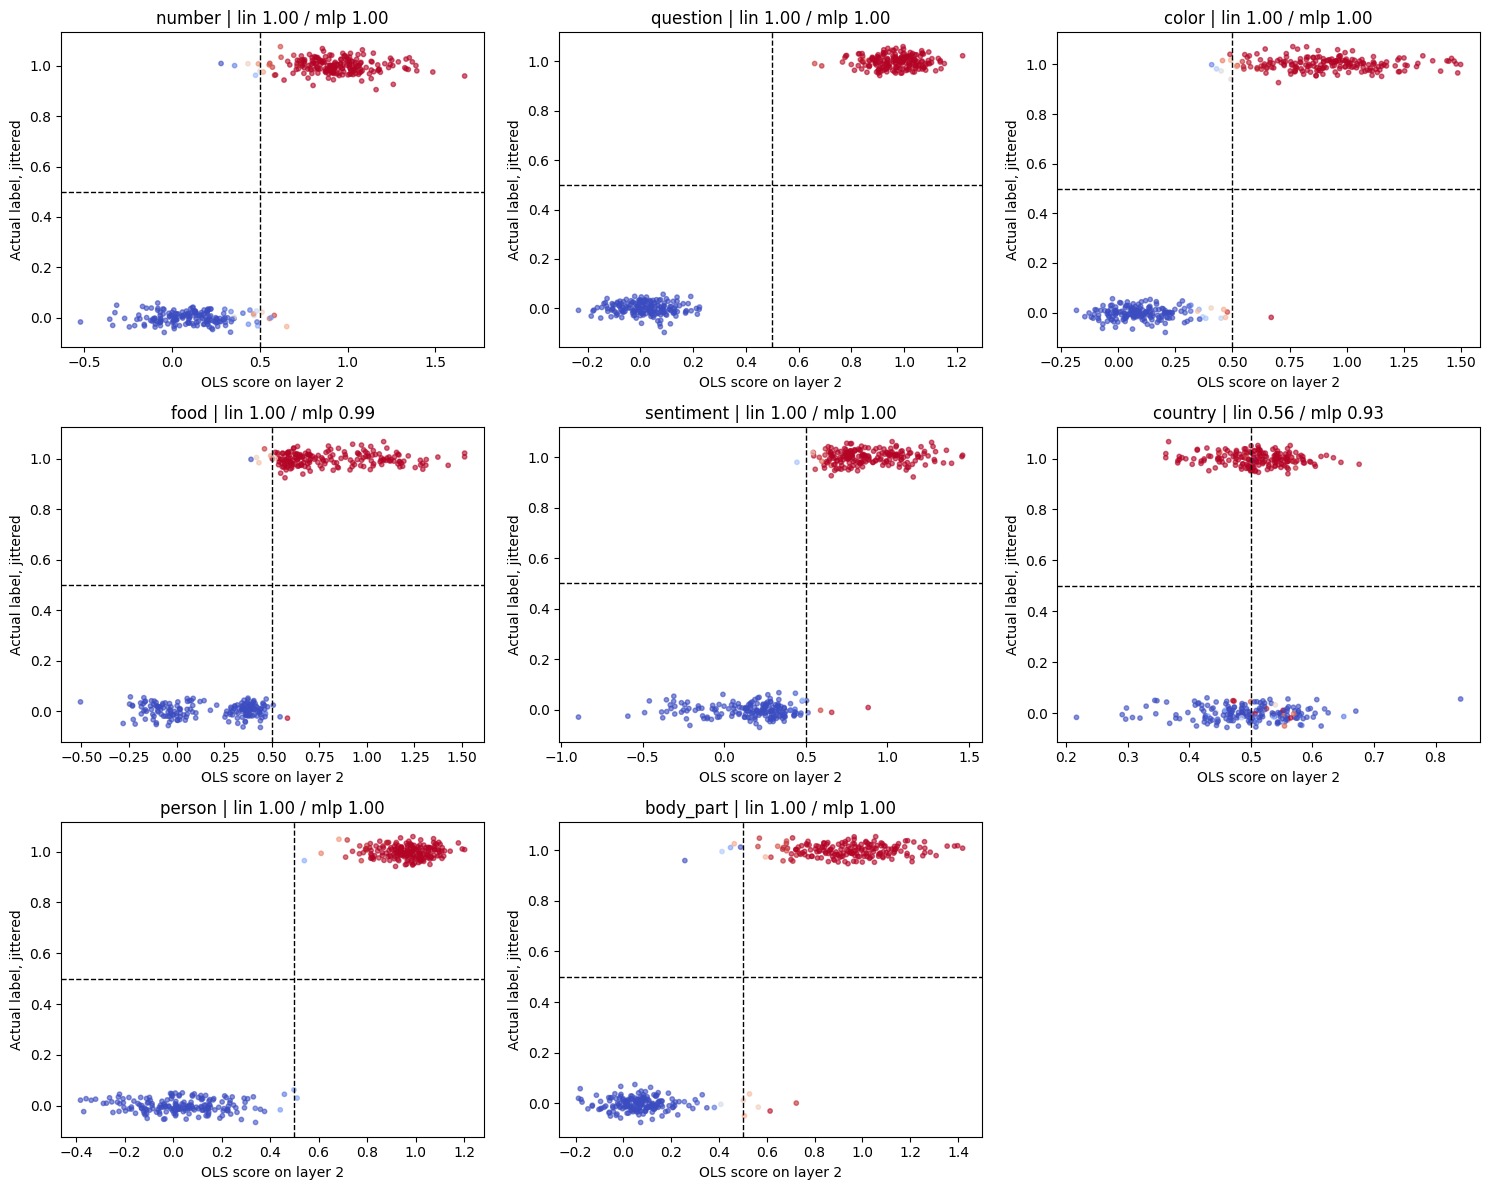


Largest gap: country (lin_auc=0.559, mlp_auc=0.935, gap=+0.376)


In [11]:
# --- 6. Linear vs nonlinear probe battery at layer 2 ---
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, roc_auc_score
from sklearn.model_selection import train_test_split
import math, json

with open("feature_names.json") as f:
    feature_names = json.load(f)

acts_np = layer2_acts.detach().cpu().numpy()
actuals_np = actuals.detach().cpu().numpy().astype(float)
probs_np = probs.detach().cpu().numpy()

n_classes = probs.shape[1]
n_cols = 3
n_rows = math.ceil(n_classes / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

rng = np.random.default_rng(0)
results = []

for i in range(n_classes):
    y = actuals_np[:, i]
    train_idx, test_idx = train_test_split(
        np.arange(len(y)), test_size=0.25, random_state=0, stratify=y,
    )

    scaler = StandardScaler().fit(acts_np[train_idx])
    Xtr = scaler.transform(acts_np[train_idx])
    Xte = scaler.transform(acts_np[test_idx])
    Xall = scaler.transform(acts_np)

    # linear detector: OLS, score used as a ranker
    reg = LinearRegression().fit(Xtr, y[train_idx])
    test_score = reg.predict(Xte)

    # nonlinear detector: small MLP on the same activations
    mlp = MLPClassifier(hidden_layer_sizes=(64,), max_iter=2000,
                        early_stopping=True, random_state=0).fit(Xtr, y[train_idx])
    mlp_score = mlp.predict_proba(Xte)[:, 1]

    base = y[test_idx].mean()
    r2 = r2_score(y[test_idx], test_score)
    mse = mean_squared_error(y[test_idx], test_score)
    thr_acc = ((test_score > 0.5) == y[test_idx]).mean()
    lin_auc = roc_auc_score(y[test_idx], test_score)
    mlp_auc = roc_auc_score(y[test_idx], mlp_score)
    gap = mlp_auc - lin_auc
    results.append((feature_names[i], base, r2, lin_auc, mlp_auc, gap))

    print(f"{feature_names[i]:<24} base={base:.2f}  R^2={r2:+.3f}  "
          f"lin_auc={lin_auc:.3f}  mlp_auc={mlp_auc:.3f}  gap={gap:+.3f}")

    # scatter: test points only, x = OLS score, colored by model's own prob
    ax = axes[i // n_cols][i % n_cols]
    y_jit = y[test_idx] + rng.normal(0, 0.025, size=len(test_idx))
    ax.scatter(test_score, y_jit, c=probs_np[test_idx, i],
               cmap="coolwarm", s=10, alpha=0.6)
    ax.axhline(0.5, color="black", ls="--", lw=1)
    ax.axvline(0.5, color="black", ls="--", lw=1)
    ax.set_title(f"{feature_names[i]} | lin {lin_auc:.2f} / mlp {mlp_auc:.2f}")
    ax.set_xlabel("OLS score on layer 2")
    ax.set_ylabel("Actual label, jittered")

for j in range(n_classes, n_rows * n_cols):
    axes[j // n_cols][j % n_cols].axis("off")
plt.tight_layout()
plt.show()

# culprit = largest linear→nonlinear gap
culprit = max(results, key=lambda r: r[5])
print(f"\nLargest gap: {culprit[0]} "
      f"(lin_auc={culprit[3]:.3f}, mlp_auc={culprit[4]:.3f}, gap={culprit[5]:+.3f})")

In [12]:
import numpy as np
from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

culprit = "country" 
c = feature_names.index(culprit)
print(f"{c} == 5?")
y_c = actuals_np[:, c].astype(int)
others = [i for i in range(len(feature_names)) if i != c]

Xs = StandardScaler().fit_transform(acts_np)    # standardized acts, reused below

5 == 5?


In [13]:
print("Boolean-combination match rates (best per pair):")
hits = []
for i, j in combinations(others, 2):
    a, b = actuals_np[:, i].astype(int), actuals_np[:, j].astype(int)
    cand = {"XOR": a ^ b, "AND": a & b, "OR": a | b, "XNOR": 1 - (a ^ b)}
    for op, v in cand.items():
        rate = (v == y_c).mean()
        hits.append((rate, op, feature_names[i], feature_names[j]))
for rate, op, fi, fj in sorted(hits, reverse=True)[:6]:
    print(f"  {rate:.3f}  {op}({fi}, {fj})")

Boolean-combination match rates (best per pair):
  0.537  OR(question, person)
  0.531  AND(question, sentiment)
  0.528  AND(question, person)
  0.528  AND(color, person)
  0.525  XOR(sentiment, body_part)
  0.524  AND(sentiment, person)


In [14]:
def auc_linear(X, y):
    tr, te = train_test_split(np.arange(len(y)), test_size=0.25,
                              random_state=0, stratify=y)
    p = LogisticRegression(max_iter=2000).fit(X[tr], y[tr]).predict_proba(X[te])[:, 1]
    return roc_auc_score(y[te], p)

marginal = auc_linear(Xs, y_c)
print(f"marginal linear AUC = {marginal:.3f}")
for j in others:
    for v in (0, 1):
        mask = actuals_np[:, j].astype(int) == v
        if mask.sum() < 50 or y_c[mask].min() == y_c[mask].max():
            continue
        a = auc_linear(Xs[mask], y_c[mask])
        if a - marginal > 0.05:
            print(f"  conditioned on {feature_names[j]}={v}: AUC={a:.3f}  (+{a-marginal:.3f})")

marginal linear AUC = 0.553
  conditioned on number=0: AUC=0.654  (+0.101)
  conditioned on food=0: AUC=0.964  (+0.411)
  conditioned on food=1: AUC=0.963  (+0.410)
  conditioned on sentiment=0: AUC=0.904  (+0.351)
  conditioned on sentiment=1: AUC=0.927  (+0.374)


In [15]:
# 1. is "sentiment rescues it too" just food in disguise?
fi, fj = feature_names.index("food"), feature_names.index("sentiment")
print("food/sentiment corr:", np.corrcoef(actuals_np[:, fi], actuals_np[:, fj])[0,1])

# 2. measure the angle between the culprit's direction in each food subgroup
from sklearn.linear_model import LogisticRegression
def dir_in(mask):
    return LogisticRegression(max_iter=2000).fit(Xs[mask], y_c[mask]).coef_[0]

m0 = actuals_np[:, fi].astype(int) == 0
m1 = actuals_np[:, fi].astype(int) == 1
d0, d1 = dir_in(m0), dir_in(m1)
cos = d0 @ d1 / (np.linalg.norm(d0) * np.linalg.norm(d1))
print(f"cos(d0, d1) = {cos:.3f}")

food/sentiment corr: -0.026744657177060902
cos(d0, d1) = -0.865


In [16]:
fs = feature_names.index("sentiment")
m0s = actuals_np[:, fs].astype(int) == 0
m1s = actuals_np[:, fs].astype(int) == 1
ds0, ds1 = dir_in(m0s), dir_in(m1s)
print("cos sentiment-subgroup dirs:", ds0 @ ds1 / (np.linalg.norm(ds0)*np.linalg.norm(ds1)))

cos sentiment-subgroup dirs: -0.91794251548626


In [19]:
fi, fs = feature_names.index("food"), feature_names.index("sentiment")
cells, labels = [], []
for a in (0,1):
    for b in (0,1):
        m = (actuals_np[:, fi].astype(int)==a) & (actuals_np[:, fs].astype(int)==b)
        cells.append(dir_in(m)); labels.append(f"f={a},s={b}")
import numpy as np
C = np.array([[c1@c2/(np.linalg.norm(c1)*np.linalg.norm(c2)) for c2 in cells] for c1 in cells])
print(labels); print(np.round(C, 2))

['f=0,s=0', 'f=0,s=1', 'f=1,s=0', 'f=1,s=1']
[[ 1.    0.28 -0.47 -0.98]
 [ 0.28  1.   -0.92 -0.17]
 [-0.47 -0.92  1.    0.41]
 [-0.98 -0.17  0.41  1.  ]]


In [21]:
u_hat = dir_in(actuals_np[:, fi].astype(int) == 0)   # food=0 direction
v_hat = dir_in(actuals_np[:, fs].astype(int) == 0)   # sentiment=0 direction
print("cos(u_food, v_sent):", u_hat @ v_hat / (np.linalg.norm(u_hat)*np.linalg.norm(v_hat)))

cos(u_food, v_sent): 0.357893315929864


In [ ]:
import torch

rest_of_model = m.layers[6:]    # Linear(64,64), ReLU, Linear(64,8)

# u from the food=0 subgroup probe, in ORIGINAL activation units
# (dir_in was fit on standardized acts, so un-standardize the direction)
sc = StandardScaler().fit(acts_np)
u_std = dir_in(actuals_np[:, fi].astype(int) == 0)
u_orig = u_std / sc.scale_                      # undo per-dim scaling
u_orig /= np.linalg.norm(u_orig)
u_t = torch.tensor(u_orig, dtype=layer2_acts.dtype)

def culprit_prob(acts):
    with torch.no_grad():
        out = rest_of_model(acts)               # <- layer2 acts -> logits, adapt!
        return torch.sigmoid(out[:, c])     u-coord p10/p90: [-0.48285659  0.2225335 ]  v-coord p10/p90: [-0.13271249  0.0779082 ]
    u     v | f0s0     f0s1     f1s0     f1s1   (mean Δlogit)
-0.34 -0.10 |  -0.174   +0.116   -1.284   +4.291
-0.34  0.10 |  +0.349   -0.002   -2.621   +2.170
 0.34 -0.10 |  +7.977   +4.513   -2.296   -3.615
 0.34  0.10 |  +8.665   +3.710   -3.117   -4.974    # culprit's output prob

base = culprit_prob(layer2_acts)

alphas = [-8, -4, -2, 0, 2, 4, 8]               # scale to activation norms if needed
food = actuals_np[:, fi].astype(int)
print(f"{'alpha':>6} | {'Δprob food=0':>13} | {'Δprob food=1':>13}")
for a in alphas:
    steered = culprit_prob(layer2_acts + a * u_t)
    d = (steered - base).cpu().numpy()
    print(f"{a:>6} | {d[food==0].mean():>+13.3f} | {d[food==1].mean():>+13.3f}")

 alpha |  Δprob food=0 |  Δprob food=1
    -8 |        -0.522 |        -0.535
    -4 |        -0.522 |        -0.535
    -2 |        -0.522 |        -0.535
     0 |        +0.000 |        +0.000
     2 |        -0.160 |        -0.531
     4 |        -0.485 |        -0.535
     8 |        -0.522 |        -0.535


In [26]:
alphas = [-1.0, -0.5, -0.25, 0, 0.25, 0.5, 1.0]   # scale to ~5–20% of mean norm
for a in alphas:
    steered = culprit_prob(torch.clamp(layer2_acts + a * u_t, min=0))
    d = (steered - base).cpu().numpy()
    print(f"{a:>6} | {d[food==0].mean():>+13.3f} | {d[food==1].mean():>+13.3f}")

  -1.0 |        -0.521 |        -0.312
  -0.5 |        -0.278 |        +0.002
 -0.25 |        -0.042 |        +0.009
     0 |        +0.000 |        +0.000
  0.25 |        +0.031 |        -0.045
   0.5 |        +0.087 |        -0.182
   1.0 |        +0.134 |        -0.507


In [29]:
proj = (layer2_acts @ u_t).unsqueeze(1) * u_t      # current u-component
for target in [-0.8, -0.5, 0.0, 0.5, .8]:         # set the u-coordinate directly
    edited = torch.clamp(layer2_acts - proj + target * u_t, min=0)
    d = (culprit_prob(edited) - base).cpu().numpy()
    print(f"set u-coord={target:>5} | food=0: {d[food==0].mean():+.3f} | food=1: {d[food==1].mean():+.3f}")

set u-coord= -0.8 | food=0: -0.423 | food=1: -0.092
set u-coord= -0.5 | food=0: -0.059 | food=1: +0.016
set u-coord=  0.0 | food=0: +0.062 | food=1: +0.002
set u-coord=  0.5 | food=0: +0.248 | food=1: -0.225
set u-coord=  0.8 | food=0: +0.204 | food=1: -0.458


In [ ]:
# v direction, same recipe as u
v_std = dir_in(actuals_np[:, fs].astype(int) == 0)
v_orig = v_std / sc.scale_; v_orig /= np.linalg.norm(v_orig)
v_t = torch.tensor(v_orig, dtype=layer2_acts.dtype)
u-coord p10/p90: [-0.48285659  0.2225335 ]  v-coord p10/p90: [-0.13271249  0.0779082 ]
    u     v | f0s0     f0s1     f1s0     f1s1   (mean Δlogit)
-0.34 -0.10 |  -0.174   +0.116   -1.284   +4.291
-0.34  0.10 |  +0.349   -0.002   -2.621   +2.170
 0.34 -0.10 |  +7.977   +4.513   -2.296   -3.615
 0.34  0.10 |  +8.665   +3.710   -3.117   -4.974
# natural coordinate ranges — stay inside them
cu, cv = acts_np @ u_orig, acts_np @ v_orig
print("u-coord p10/p90:", np.percentile(cu, [10, 90]),
      " v-coord p10/p90:", np.percentile(cv, [10, 90]))

def culprit_logit(acts):
    with torch.no_grad():
        return m.layers[6:](acts)[:, c]      # logit, not prob

base_l = culprit_logit(layer2_acts)
pu = (layer2_acts @ u_t).unsqueeze(1) * u_t      # current components
pv = (layer2_acts @ v_t).unsqueeze(1) * v_t
stripped = layer2_acts - pu - pv

su, sv_ = 0.7 * np.percentile(np.abs(cu), 90), 0.7 * np.percentile(np.abs(cv), 90)
sent = actuals_np[:, fs].astype(int)
print(f"{'u':>5} {'v':>5} | f0s0     f0s1     f1s0     f1s1   (mean Δlogit)")
for au in (-su, su):
    for av in (-sv_, sv_):
        edited = torch.clamp(stripped + au * u_t + av * v_t, min=0)
        d = (culprit_logit(edited) - base_l).cpu().numpy()
        row = [d[(food==a)&(sent==b)].mean() for a in (0,1) for b in (0,1)]
        print(f"{au:>5.2f} {av:>5.2f} | " + "  ".join(f"{x:+7.3f}" for x in row))

u-coord p10/p90: [-0.48285659  0.2225335 ]  v-coord p10/p90: [-0.13271249  0.0779082 ]
    u     v | f0s0     f0s1     f1s0     f1s1   (mean Δlogit)
-0.34 -0.10 |  -0.174   +0.116   -1.284   +4.291
-0.34  0.10 |  +0.349   -0.002   -2.621   +2.170
 0.34 -0.10 |  +7.977   +4.513   -2.296   -3.615
 0.34  0.10 |  +8.665   +3.710   -3.117   -4.974


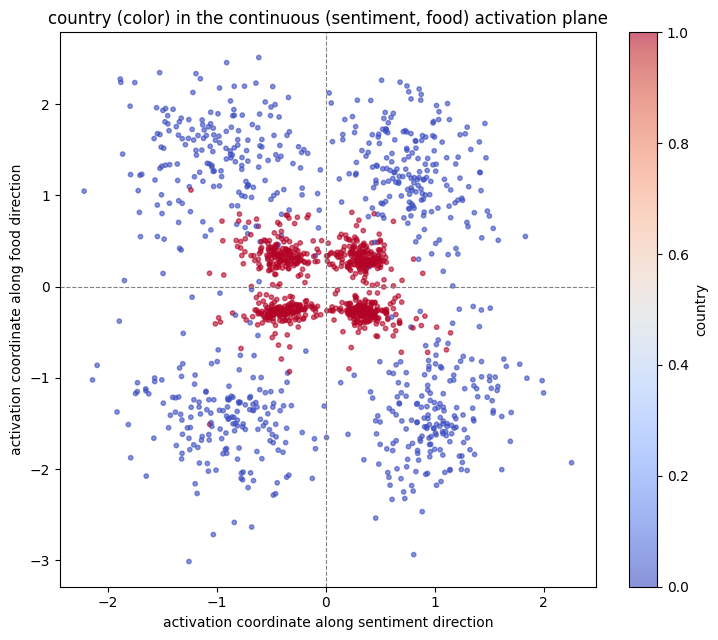

In [32]:
from sklearn.linear_model import LogisticRegression

fi, fs = feature_names.index("food"), feature_names.index("sentiment")
cc = feature_names.index("country")
country = actuals_np[:, cc].astype(int)

# continuous coordinates: projections onto the food and sentiment probe directions
d_food = LogisticRegression(max_iter=2000).fit(Xs, actuals_np[:, fi]).coef_[0]
d_sent = LogisticRegression(max_iter=2000).fit(Xs, actuals_np[:, fs]).coef_[0]
x = Xs @ (d_sent / np.linalg.norm(d_sent))     # sentiment coordinate
y = Xs @ (d_food / np.linalg.norm(d_food))     # food coordinate

fig, ax = plt.subplots(figsize=(7.5, 6.5))
sc_ = ax.scatter(x, y, c=country, cmap="coolwarm", s=10, alpha=0.6)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.axvline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("activation coordinate along sentiment direction")
ax.set_ylabel("activation coordinate along food direction")
ax.set_title("country (color) in the continuous (sentiment, food) activation plane")
plt.colorbar(sc_, label="country")
plt.tight_layout(); plt.show()

In [33]:
r = np.sqrt(x**2 + y**2)                      # radius in this plane
from sklearn.metrics import roc_auc_score
print("AUC of radius for country:", roc_auc_score(country, -r))   # minus: small r → country=1

AUC of radius for country: 0.9932566970793836
